## Expérimentation de modèles

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import (
    Lasso, LassoCV,
    Ridge, LinearRegression
)
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    GridSearchCV,
    learning_curve,
    HalvingGridSearchCV
)
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score, get_scorer_names

In [2]:
train_data = pd.read_csv("../data/processed_dataset.csv")
test_data = pd.read_parquet("../data/test_data.parquet")

X_train = train_data.drop(
    ["LoyerMensuel_Log1", "LoyerMensuel_BIF", "IdentifiantMaison"],
    axis=1).select_dtypes(include=["number"])
y_train = train_data["LoyerMensuel_Log1"]

print(X_train)

     Chambres  Superficie_m2  DistanceRoute_m  AgeMaison  Salon_Bin  \
0         1.0      -1.591270         0.010545   0.040397          1   
1         4.0       0.701481         0.691637   0.306172          1   
2         4.0       0.218797        -1.084717   0.394764          1   
3         6.0       1.184165         1.223335  -1.554256          1   
4         3.0      -0.035954        -1.507659   1.280682          1   
..        ...            ...              ...        ...        ...   
377       4.0       0.245612         0.715805  -0.491154          1   
378       6.0       0.052373         1.162914   1.280682          1   
379       5.0       0.781928         1.682528  -0.313970          1   
380       6.0       1.640034        -1.568079   0.926315          1   
381       6.0       1.438915         0.981654   1.014907          1   

     SalleDeBainInterieure_Bin  Parking_Bin  Meuble_Bin  Jardin_Bin  \
0                            1            0           0           0   
1    

### Transformation de données de test

In [3]:
cols_a_scaler = ["Superficie_m2", "DistanceRoute_m", "AgeMaison"]

for col in ['Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin']:
    test_data[col + "_Bin"] = test_data[col].map({"Oui": 1, "Non": 0}).fillna(0).astype(int)

scaler = joblib.load("scaler.joblib")
print(scaler.mean_)
scaler_values = scaler.transform(test_data[cols_a_scaler])
print(scaler_values)
scaled_df = pd.DataFrame(scaler_values, columns=cols_a_scaler, index=test_data.index)
test_data[cols_a_scaler] = scaled_df

neighbourhood_encoder = joblib.load("neighbourhood_encoder.joblib")
test_data["Quartier_Target"] = neighbourhood_encoder.transform(test_data[["Quartier"]])[:, 0]

test_data["LoyerMensuel_Log1"] = np.log1p(test_data["LoyerMensuel_BIF"])

# Création de variables utiles pour le test
# cols_confort = ['Salon_Bin', 'SalleDeBainInterieure_Bin', 'Parking_Bin', 'Meuble_Bin', 'Jardin_Bin']
# test_data['Indicateur_Confort'] = test_data[cols_confort].sum(axis=1)

# test_data['Chambres_par_Superficie'] = test_data['Chambres'] / (test_data['Superficie_m2'] + 0.1)

# Séparation de X_test et y_test
X_test = test_data.drop(
    ["LoyerMensuel_Log1", "LoyerMensuel_BIF", "IdentifiantMaison"],
    axis=1).select_dtypes(include=["number"])
y_test = test_data["LoyerMensuel_Log1"]

X_test

[164.68151886 153.76444109  19.54401144]
[[-2.22577339 -1.83674182 -1.85343697]
 [-2.21462754 -1.87061939 -1.60228461]
 [-2.19107744 -1.87573023 -1.71216377]
 [-2.19287515 -1.85966759 -1.86128548]
 [-2.230807   -1.85922952 -1.67292121]
 [-2.19305493 -1.83951627 -1.61013312]
 [-2.23188563 -1.86959722 -1.72001228]
 [-2.18820109 -1.85514085 -1.7357093 ]
 [-2.20743667 -1.86039771 -1.60228461]
 [-2.19233584 -1.83747194 -1.72837863]
 [-2.18352702 -1.83717989 -1.65722419]
 [-2.23152608 -1.85796829 -1.71216377]
 [-2.19521219 -1.8615659  -1.82204293]
 [-2.18460565 -1.87894276 -1.64937568]
 [-2.20733103 -1.87573023 -1.69646674]
 [-2.22433521 -1.87193361 -1.83773995]
 [-2.18388657 -1.85397265 -1.65722419]
 [-2.20312214 -1.84010037 -1.75140632]
 [-2.20815575 -1.83674182 -1.71216377]
 [-2.18820109 -1.84725555 -1.61013312]
 [-2.23134631 -1.87061939 -1.72001228]
 [-2.20312214 -1.87456204 -1.57873908]
 [-2.18766177 -1.86434036 -1.83773995]
 [-2.22559361 -1.86331819 -1.5944361 ]
 [-2.22451498 -1.871495

,Chambres,Superficie_m2,DistanceRoute_m,AgeMaison,Salon_Bin,SalleDeBainInterieure_Bin,Parking_Bin,Meuble_Bin,Jardin_Bin,Quartier_Target
0,1.000000,-2.225773,-1.836742,-1.853437,1,1,1,0,0,0.010428
1,2.000000,-2.214628,-1.870619,-1.602285,1,1,1,0,0,0.001998
2,5.000000,-2.191077,-1.875730,-1.712164,1,1,0,0,1,0.010428
3,3.521649,-2.192875,-1.859668,-1.861285,1,1,0,0,0,0.002163
4,1.000000,-2.230807,-1.859230,-1.672921,0,1,1,0,0,0.002146
...,...,...,...,...,...,...,...,...,...,...
123,4.000000,-2.200246,-1.853389,-1.680770,1,1,1,0,1,0.002029
124,5.000000,-2.200785,-1.862004,-1.790649,1,1,1,0,1,0.001998
125,6.000000,-2.191976,-1.863902,-1.657224,1,1,1,0,1,0.002014
126,4.000000,-2.205639,-1.849446,-1.767103,1,1,0,1,1,0.002163


In [4]:
def formated_time(second):
    m, s = divmod(second, 60)

    if m > 0:
         f"{int(m)} min {s:.4f} secondes"
    else:
        return f"{s:.4f} secondes"

scoring = ["neg_mean_squared_error", "neg_median_absolute_error", "neg_root_mean_squared_error", "r2"]

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve


def _learning_curve(model, model_name, X=X_train, y=y_train):
    metrics = {
        "RMSE": {
            "scoring": "neg_mean_squared_error",
            "transform": lambda x: np.sqrt(-x),
            "ylabel": "RMSE",
        },
        "MAE": {
            "scoring": "neg_mean_absolute_error",
            "transform": lambda x: -x,
            "ylabel": "MAE",
        },
        "R2": {
            "scoring": "r2",
            "transform": lambda x: x,
            "ylabel": "r2_scores",
        },
    }

    fig, axes = plt.subplots(3, 3, figsize=(17, 12))
    # Utilisation stricte du tableau aplati (1D de 9 éléments : 0 à 8)
    axes_flat = axes.flatten()

    # --- 1. Les 3 Courbes d'Apprentissage (index 0, 1, 2) ---
    for i, (metric_name, metric_info) in enumerate(metrics.items()):
        ax = axes_flat[i]  # <-- Correction ici

        train_sizes, train_scores, test_scores = learning_curve(
            estimator=model,
            X=X,
            y=y,
            train_sizes=np.linspace(0.1, 1.0, 10),
            cv=10,
            scoring=metric_info["scoring"],
            n_jobs=-1,
            random_state=40,
        )

        train_scores_trans = metric_info["transform"](train_scores)
        test_scores_trans = metric_info["transform"](test_scores)

        train_mean = train_scores_trans.mean(axis=1)
        train_std = train_scores_trans.std(axis=1)
        test_mean = test_scores_trans.mean(axis=1)
        test_std = test_scores_trans.std(axis=1)

        ax.plot(
            train_sizes,
            train_mean,
            "o-",
            color="red",
            label="Score entraînement",
        )
        ax.fill_between(
            train_sizes,
            train_mean - train_std,
            train_mean + train_std,
            alpha=0.1,
            color="red",
        )

        ax.plot(
            train_sizes,
            test_mean,
            "o-",
            color="blue",
            label="Score validation",
        )
        ax.fill_between(
            train_sizes,
            test_mean - test_std,
            test_mean + test_std,
            alpha=0.1,
            color="blue",
        )

        ax.set_title(f"{metric_name}")
        ax.set_xlabel("Exemples d'entraînement")
        ax.set_ylabel(metric_info["ylabel"])
        ax.legend(loc="best")
        ax.grid(True)

    # --- Entraînement et calcul des prédictions ---
    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred

    # --- 2. Actual vs Predicted (index 3) ---
    ax_act_pred = axes_flat[3]  # <-- Correction ici
    ax_act_pred.scatter(y, y_pred, alpha=0.5, color="green")

    min_val = min(min(y), min(y_pred))
    max_val = max(max(y), max(y_pred))
    ax_act_pred.plot(
        [min_val, max_val],
        [min_val, max_val],
        "r--",
        lw=2,
        label="Parfait (y=x)",
    )

    ax_act_pred.set_title("Actual vs Predicted")
    ax_act_pred.set_xlabel("Valeurs Réelles (y)")
    ax_act_pred.set_ylabel("Valeurs Prédites (y_pred)")
    ax_act_pred.legend(loc="best")
    ax_act_pred.grid(True)

    ax_res = axes_flat[4]
    ax_res.scatter(y_pred, residuals, alpha=0.5, color="purple")
    ax_res.axhline(y=0, color="red", linestyle="--", lw=2)

    ax_res.set_title("Residual Plot")
    ax_res.set_xlabel("Valeurs Prédites (y_pred)")
    ax_res.set_ylabel("Résidus (y - y_pred)")
    ax_res.grid(True)

    # --- Nettoyage : Suppression des 4 axes vides inutilisés (index 5 à 8) ---
    for j in range(5, 9):
        fig.delaxes(axes_flat[j])

    fig.suptitle(
        f"Évaluation du Modèle - {model_name}", fontsize=16, y=1.02
    )
    plt.tight_layout()
    plt.show()

### Modèle de Régression Linéaire

Fit Time : [0.00881195 0.00580359 0.00500989 0.00829458 0.0083344 ]

Score Time : [0.00706744 0.00865579 0.0071578  0.00859213 0.00690317]

Test Neg Median Abosulte Error : [-0.29529119 -0.34190201 -0.31906953 -0.24348737 -0.34015249]

Test Neg Mean Squared Error : [-0.27982966 -0.19386591 -0.1916029  -0.14766901 -0.16562655]

Test R2 : 0.48146432535153305


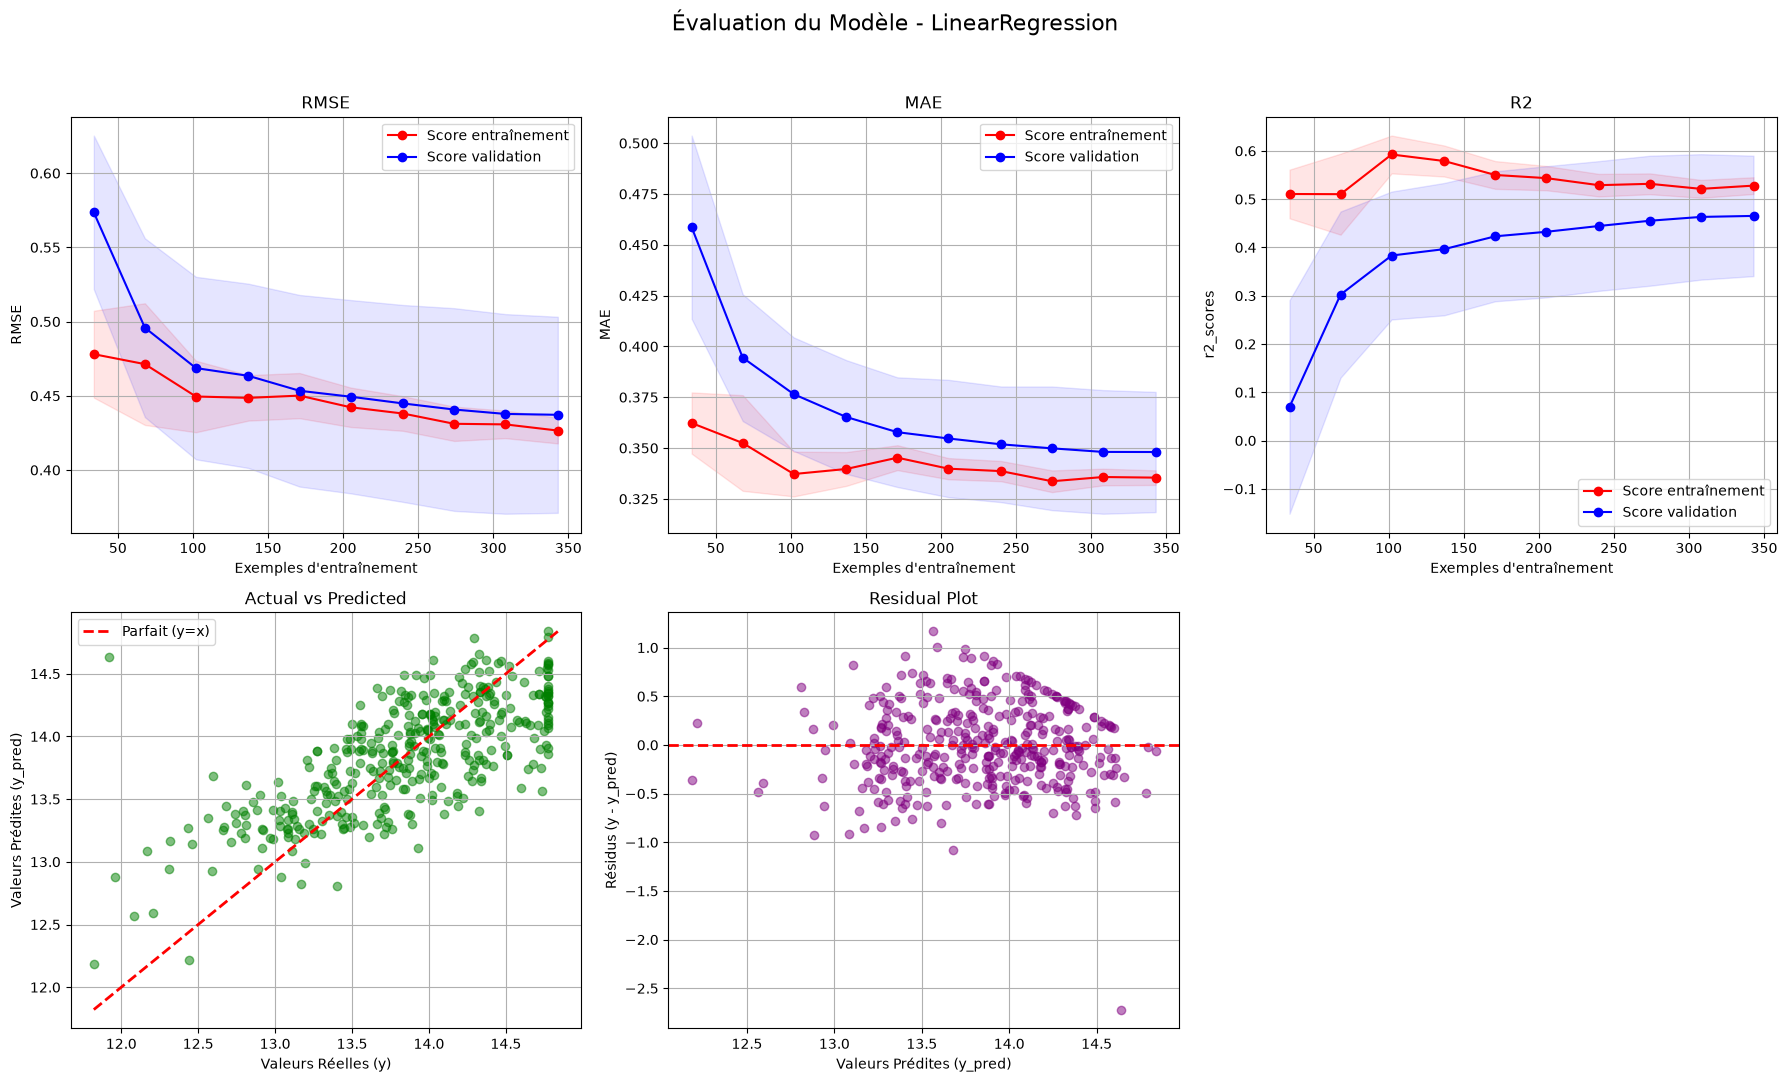

In [16]:
linear_model = LinearRegression()

linear_scores = cross_validate(linear_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {linear_scores["fit_time"]}")
print()
print(f"Score Time : {linear_scores["score_time"]}")
print()
print(f"Test Neg Median Abosulte Error : {linear_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg Mean Squared Error : {linear_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test R2 : {linear_scores["test_r2"].mean()}")

_learning_curve(
    model=linear_model,
    model_name="LinearRegression",
)

### Modèle Lasso

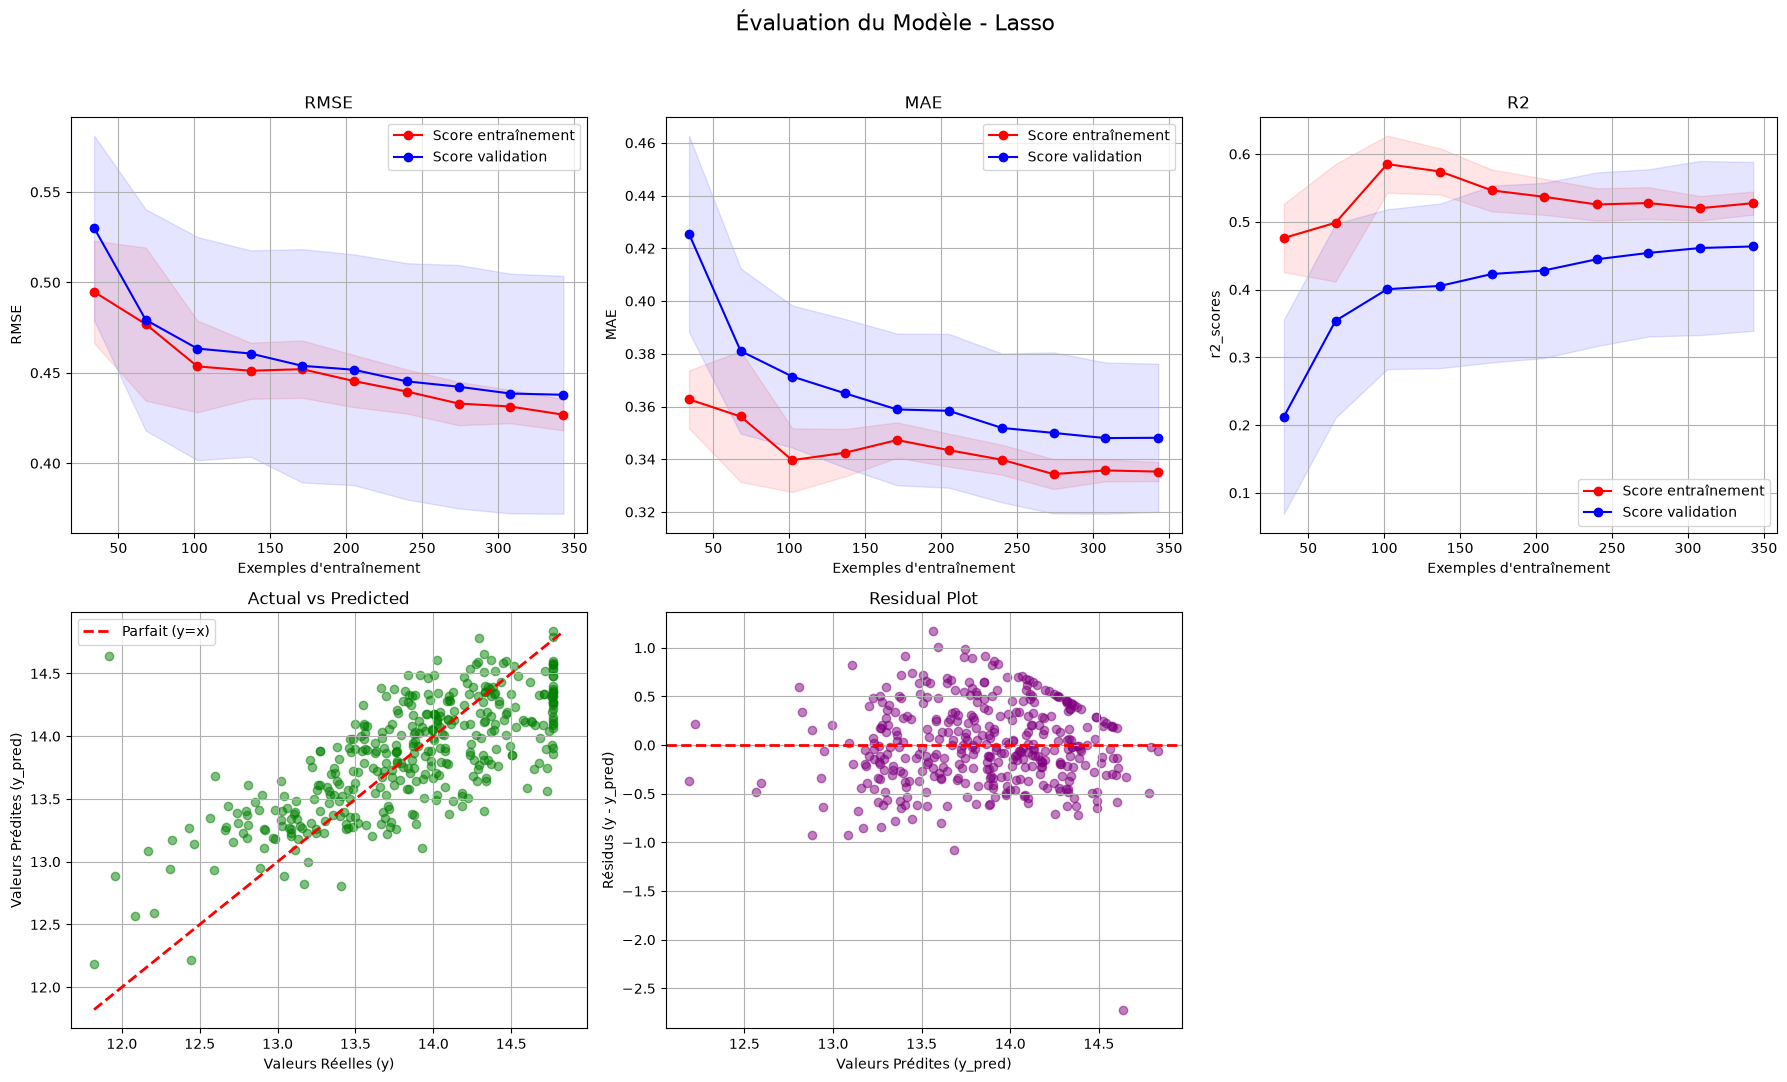

In [18]:
lasso_model = make_pipeline(StandardScaler(), LassoCV(cv=10, random_state=40))

# lasso_model.fit(X_train, y_train)

# lasso_cv = lasso_model[-1]

# alphas = lasso_cv.alphas_
# mse_mean = lasso_cv.mse_path_.mean(axis=1)
# mse_std = lasso_cv.mse_path_.std(axis=1)
# alpha_best = lasso_cv.alpha_

# print(alpha_best)

# plt.figure(figsize=(10, 6))

# plt.semilogx(alphas, lasso_cv.mse_path_, ":", alpha=0.3, label="MSE par pli")
# plt.semilogx(alphas, mse_mean, "b-", linewidth=2, label="MSE mean")

# plt.semilogx(alphas, mse_mean + mse_std, "b--", alpha=0.5)
# plt.semilogx(alphas, mse_mean + mse_std, "b--", alpha=0.5)

# plt.axvline(alpha_best, color="r", linestyle="--", label=f"Meilleur alpha : {alpha_best:.4f}")

# plt.xlabel(r"$\alpha$ Paramètres de régularisation")
# plt.ylabel("Erreur Quadratique Moyenne")
# plt.title("Sélection du modèle Lasso par validation croisée")
# plt.legend()

# plt.grid(True, which="both", ls="-", alpha=0.4)
# plt.tight_layout()
# plt.show()

_learning_curve(
    model=lasso_model,
    model_name="Lasso",
)

### Ridget Model

In [ ]:
ridge_model = Ridge(alpha=0.1)
ridge_scores = cross_validate(ridge_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {ridge_scores["fit_time"]}")
print()
print(f"Score Time : {ridge_scores["score_time"]}")
print()
print(f"Test Neg MSE : {ridge_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {ridge_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {ridge_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {ridge_scores["test_r2"]}")

_learning_curve(
    model=ridge_model,
    model_name="Ridge",
)

### Arbres de décision

Fit Time : [0.00921464 0.00435019 0.00443697 0.00510812 0.00430775]

Score Time : [0.00479484 0.00781941 0.00487542 0.00490117 0.00547433]

Test Neg MSE : [-0.34502871 -0.20881057 -0.26225622 -0.2078706  -0.24170174]

Test Neg  MAE : [-0.30006272 -0.31880388 -0.31832164 -0.26914807 -0.28353881]

Test Neg SMSE : [-0.58739144 -0.45695795 -0.51210958 -0.45592829 -0.49163171]

Test R2 : [0.24363184 0.5762679  0.17626983 0.29800093 0.29175175]


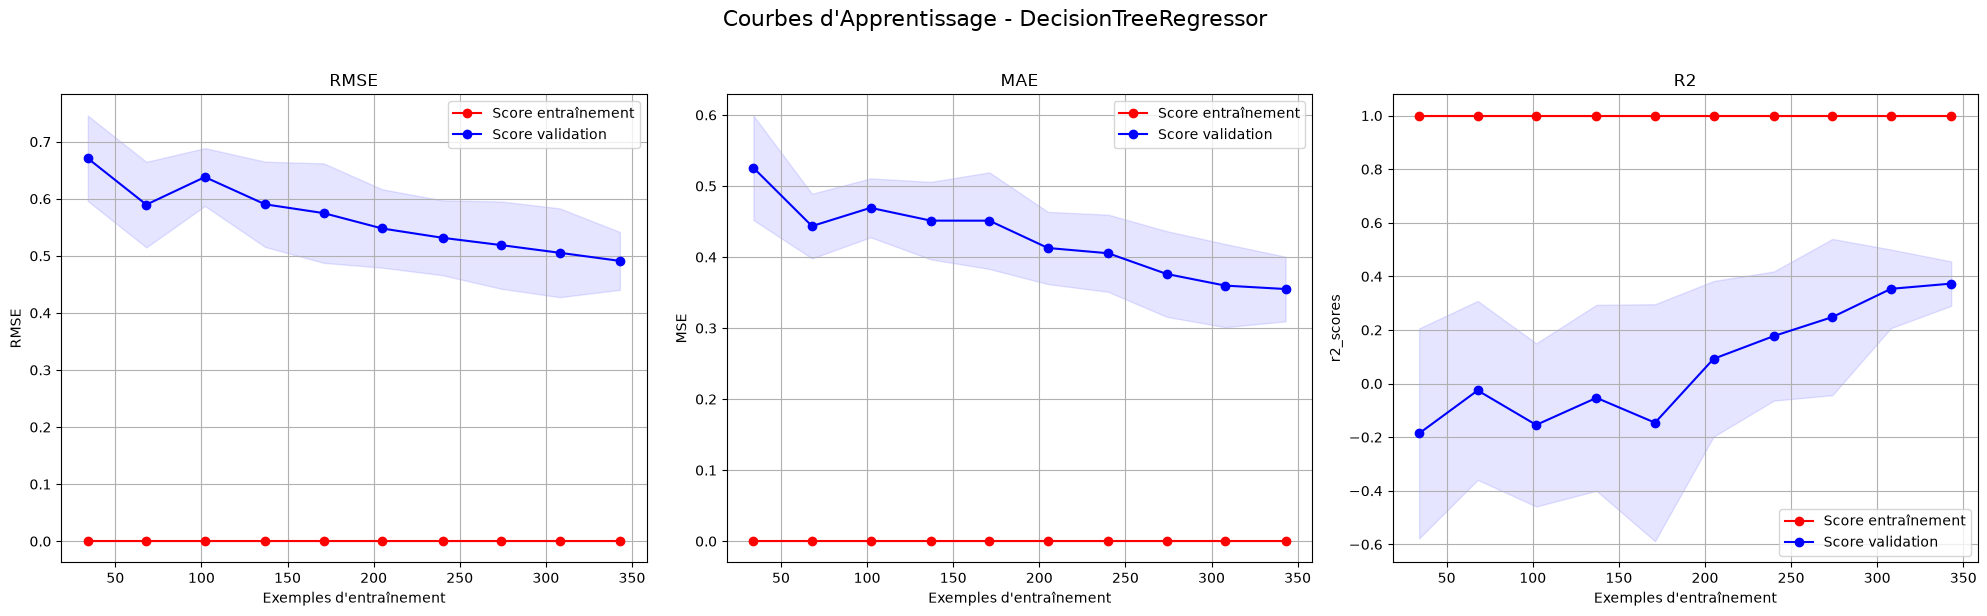

In [102]:
tree_model = DecisionTreeRegressor()
tree_scores = cross_validate(tree_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {tree_scores["fit_time"]}")
print()
print(f"Score Time : {tree_scores["score_time"]}")
print()
print(f"Test Neg MSE : {tree_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {tree_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {tree_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {tree_scores["test_r2"]}")

_learning_curve(
    model=tree_model,
    model_name="DecisionTreeRegressor",
)

### Modèle de Fôrets Aléatoire

Fit Time : [0.32821083 0.24479437 0.22037816 0.21415401 0.21429396]

Score Time : [0.02239728 0.02293086 0.0182302  0.01760387 0.0177598 ]

Test Neg MSE : [-0.20300531 -0.15117859 -0.11569701 -0.10718774 -0.12772732]

Test Neg  MAE : [-0.22785323 -0.24860636 -0.21804329 -0.22359197 -0.24979815]

Test Neg SMSE : [-0.45056111 -0.38881691 -0.34014264 -0.32739538 -0.35738959]

Test R2 : [0.55497398 0.6932185  0.63660301 0.63801669 0.62572612]


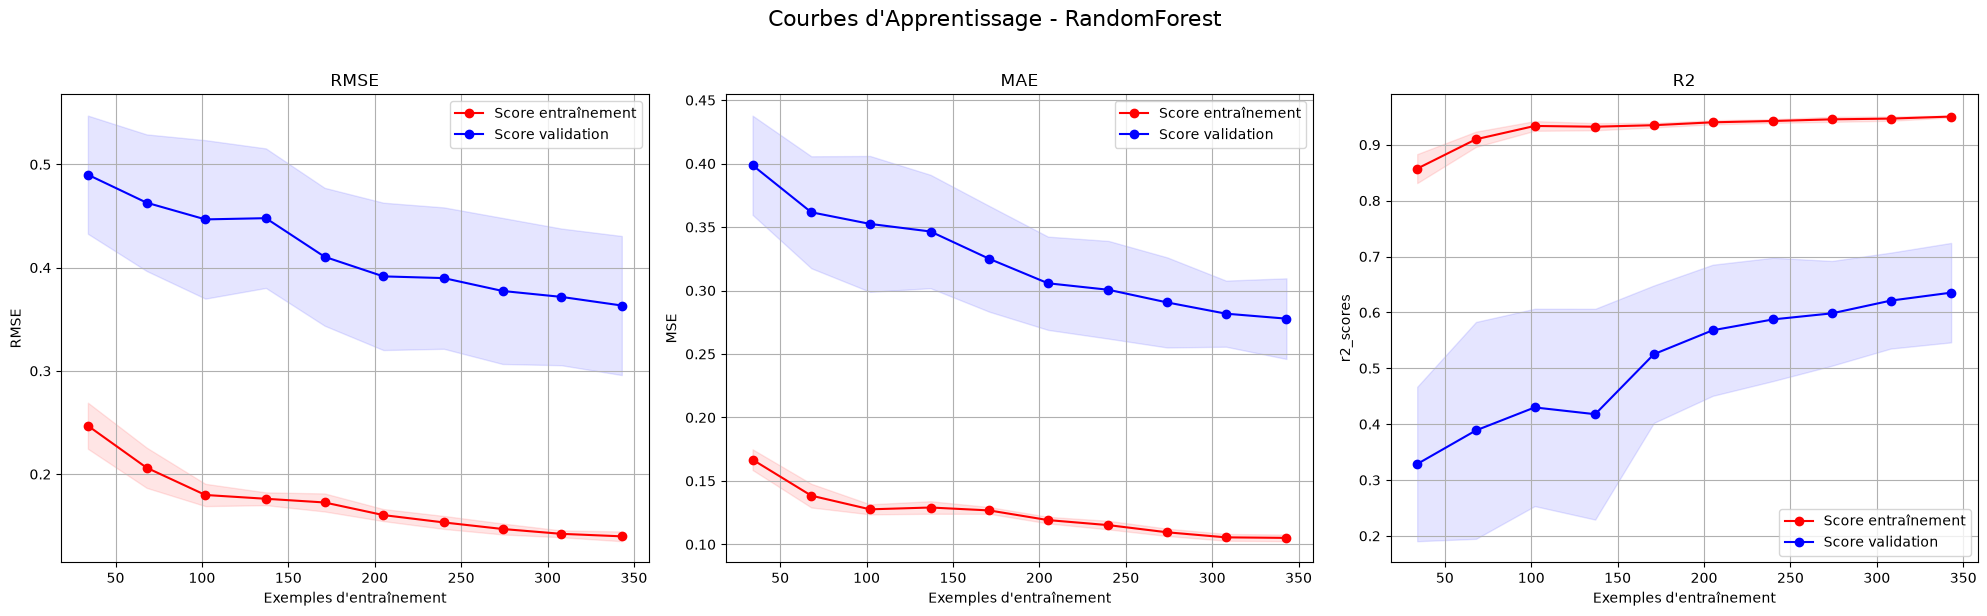

In [7]:
random_model = RandomForestRegressor()

random_scores = cross_validate(random_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {random_scores["fit_time"]}")
print()
print(f"Score Time : {random_scores["score_time"]}")
print()
print(f"Test Neg MSE : {random_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {random_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {random_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {random_scores["test_r2"]}")

_learning_curve(
    model=random_model,
    model_name="RandomForest",
)

### Modèle de Gradient Boosting

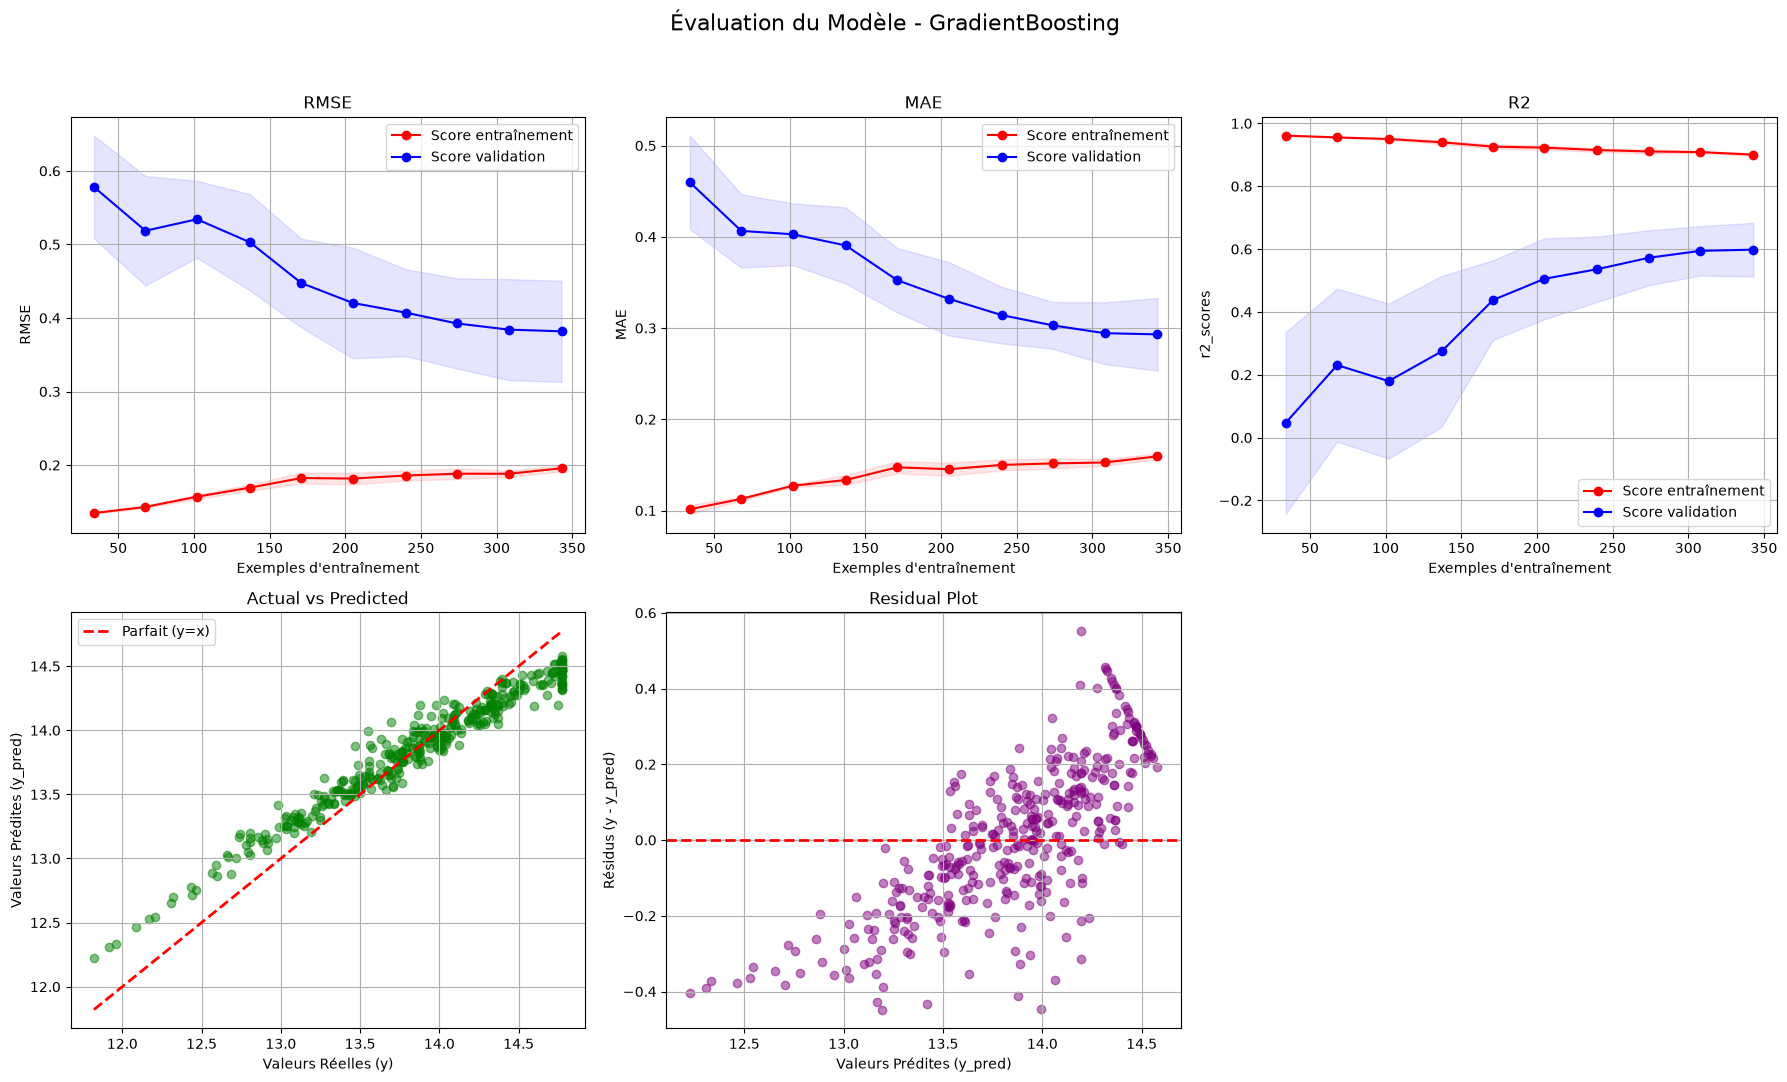

In [19]:
param_grid = {
    "n_estimators": np.linspace(50, 500, 5, dtype=int).tolist(),
    "learning_rate": np.logspace(-5, -1, 5).tolist(),
    "max_depth": np.linspace(1, 20, 4, dtype=int).tolist(),
    "subsample": np.linspace(0.5, 1.0, 4).tolist()
}

boosting_model = GradientBoostingRegressor(
    learning_rate=0.01,
    n_estimators=162,
    max_depth=7,
    random_state=42
)

# search = HalvingGridSearchCV(
#     estimator=boosting_model,
#     param_grid=param_grid,
#     factor=2,
#     aggressive_elimination=True,
#     cv=5,
#     scoring="neg_mean_squared_error",
#     n_jobs=-1,
#     random_state=42
# )

# search.fit(X_train, y_train)

# print(search.best_score_)
# print(search.best_params_)
# print(search.best_estimator_)

_learning_curve(
    model=boosting_model,
    model_name="GradientBoosting",
)